# Assignment 8 - Soil health and carbon screening

This notebook summarizes USDA NRCS SSURGO properties for the top 30 cm of the same 25 Story County fields. These are generalized screening estimates, not a farm recommendation.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
for parent in (ROOT, *ROOT.parents):
    if (parent / 'data/processed/assignment-08/soil_health_by_field.csv').is_file():
        ROOT = parent
        break

CSV_PATH = ROOT / 'data/processed/assignment-08/soil_health_by_field.csv'
SUMMARY_PATH = ROOT / 'data/processed/assignment-08/soil_health_summary.json'
FIGURE_PATH = ROOT / 'docs/assets/soil_health_metrics.png'
rows = pd.read_csv(CSV_PATH)
summary = json.loads(SUMMARY_PATH.read_text())
assert len(rows) == 25 and rows['field_id'].nunique() == 25
rows.head()

,field_id,organic_matter_pct,ph_h2o,cec_cmol_kg,erosion_k_factor,carbon_storage_mg_c_ha,soil_coverage_fraction,om_coverage_fraction,ph_coverage_fraction,cec_coverage_fraction,erosion_coverage_fraction,carbon_coverage_fraction
0,STORY-01,5.378010,6.408089,28.561661,0.275283,116.627887,1.0,1.0,1.0,1.0,1.000000,1.0
1,STORY-02,5.411615,6.557699,23.755924,0.264193,106.533325,1.0,1.0,1.0,1.0,0.997413,1.0
2,STORY-03,5.756868,6.676378,26.717554,0.237130,123.674389,1.0,1.0,1.0,1.0,1.000000,1.0
3,STORY-04,4.954392,6.436858,21.511310,0.271580,100.646922,1.0,1.0,1.0,1.0,1.000000,1.0
4,STORY-05,5.252214,6.440760,22.533877,0.274118,105.171270,1.0,1.0,1.0,1.0,1.000000,1.0


## Method and weighting

SSURGO horizon records are clipped to 0-30 cm. Organic matter, cation exchange capacity (CEC), and erosion K-factor use horizon-thickness weighting. pH is averaged in hydrogen-ion concentration space because pH is logarithmic. Carbon storage sums the stocks of the clipped horizons vertically. Component results are weighted by normalized `comppct_r`, then mapunit results are weighted by Assignment 4 field intersection fractions. Missing properties are not imputed; each metric retains its own coverage fraction.

## Organic matter (%)

Organic matter is a weight percentage for the less-than-2-mm soil material. It is a map-based screening indicator, not a substitute for field sampling.

## pH (1:1 H2O)

The pH estimate uses concentration-space weighting before conversion back to pH units, avoiding a misleading arithmetic average of logarithmic values.

## Cation exchange capacity (cmol(+)/kg)

CEC is summarized over the top 30 cm as a screening description of the mapped soil components.

## Erosion K-factor

`kwfact` is used as a soil-erodibility proxy. It does not include slope, cover, rainfall erosivity, or management and therefore is not a field erosion prediction.

## Carbon stock screening estimate (Mg C/ha)

Organic matter is converted to soil organic carbon with `SOC % = OM % / 1.724`. Horizon stock is `bulk density (g/cm3) × clipped thickness (cm) × SOC %`; horizon stocks are summed through 30 cm. Rock-fragment corrections and measured local bulk density are unavailable, so this remains a screening estimate.

In [2]:
metric_table = pd.DataFrame(summary['metrics']).T
metric_table[['unit', 'mean', 'median', 'non_null_fields', 'mean_coverage_fraction']].round(4)

,unit,mean,median,non_null_fields,mean_coverage_fraction
carbon_storage_mg_c_ha,Mg C/ha,97.52984,100.646922,25,0.999991
cec_cmol_kg,cmol(+)/kg,22.389324,22.648138,25,0.999991
erosion_k_factor,dimensionless K factor,0.271786,0.274257,25,0.996851
organic_matter_pct,%,4.73697,4.954392,25,0.999991
ph_h2o,pH units,6.433874,6.420679,25,0.999991


## Coverage and missingness

Coverage is reported separately for organic matter, pH, CEC, erosion K-factor, and carbon because SSURGO property availability differs by component. A metric value is normalized over its covered field fraction only; an unavailable component is not treated as zero.

In [3]:
coverage_columns = [column for column in rows if column.endswith('_coverage_fraction')]
coverage = rows[['field_id', *coverage_columns]].copy()
assert coverage[coverage_columns].apply(lambda column: column.between(0, 1).all()).all()
coverage.describe().round(4)

,soil_coverage_fraction,om_coverage_fraction,ph_coverage_fraction,cec_coverage_fraction,erosion_coverage_fraction,carbon_coverage_fraction
count,25.0000,25.0000,25.0000,25.0000,25.0000,25.0000
mean,1.0000,1.0000,1.0000,1.0000,0.9969,1.0000
std,0.0000,0.0000,0.0000,0.0000,0.0139,0.0000
min,0.9998,0.9998,0.9998,0.9998,0.9303,0.9998
25%,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
50%,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
75%,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


## Five-metric field comparison

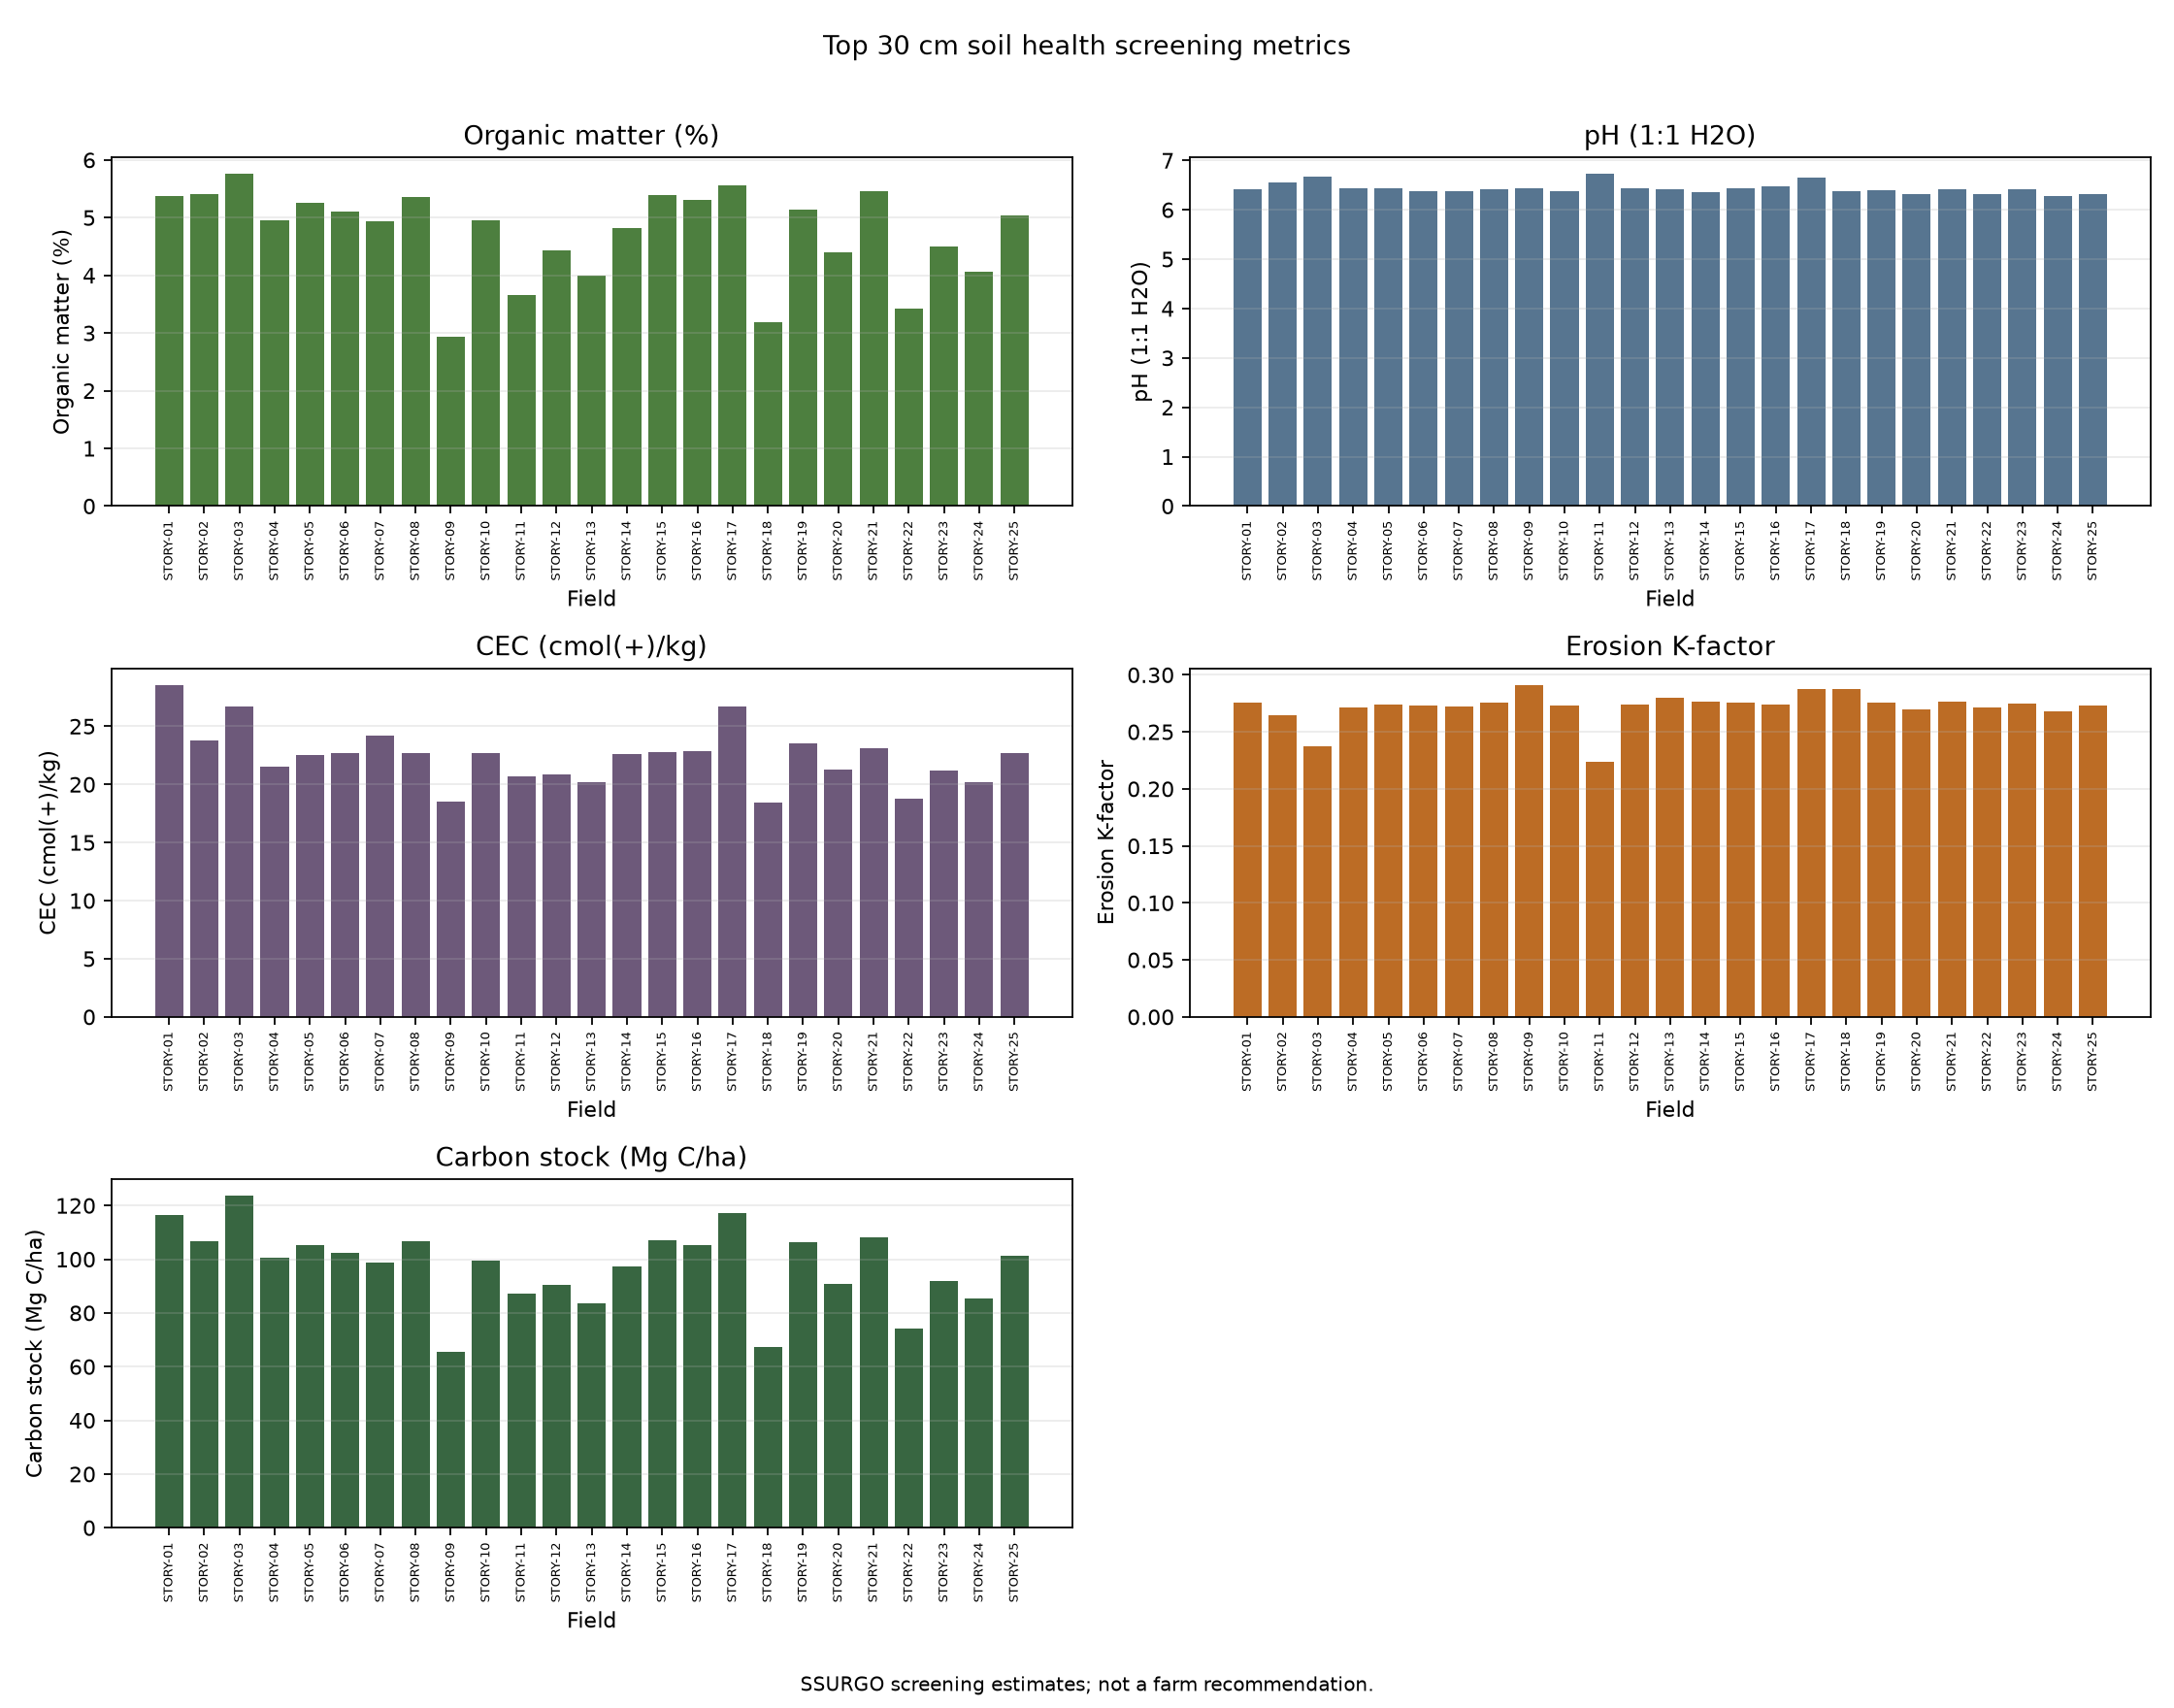

In [4]:
display(Image(filename=str(FIGURE_PATH)))

## Interpretation and limitations

SSURGO polygons and component percentages generalize variable soils within each mapunit. The analysis does not include laboratory samples, rock-fragment adjustment, local management, slope-process modeling, or uncertainty intervals. Differences among fields are descriptive screening signals only. They are not a farm recommendation, fertilizer prescription, carbon-credit estimate, or operational erosion assessment.